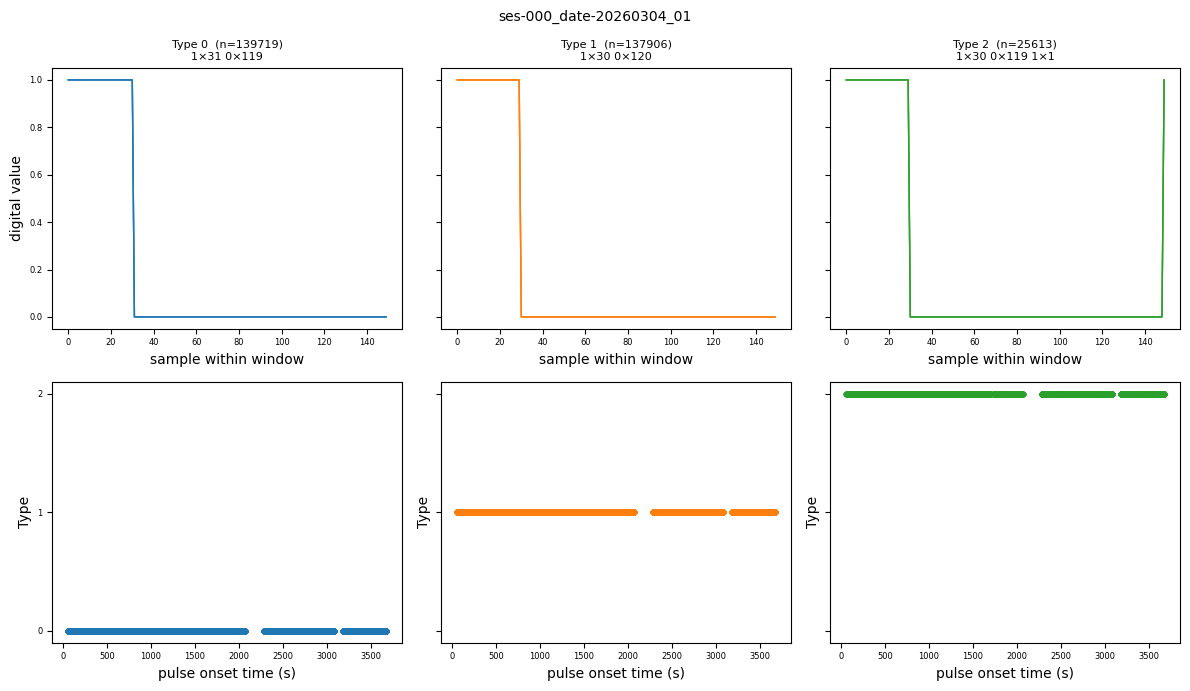

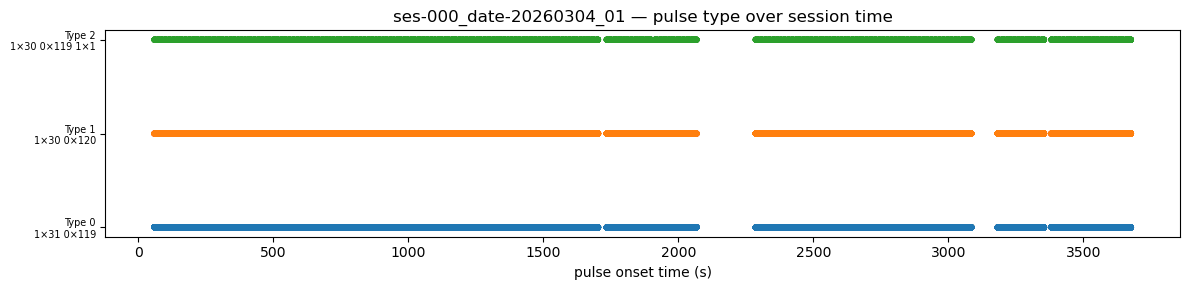

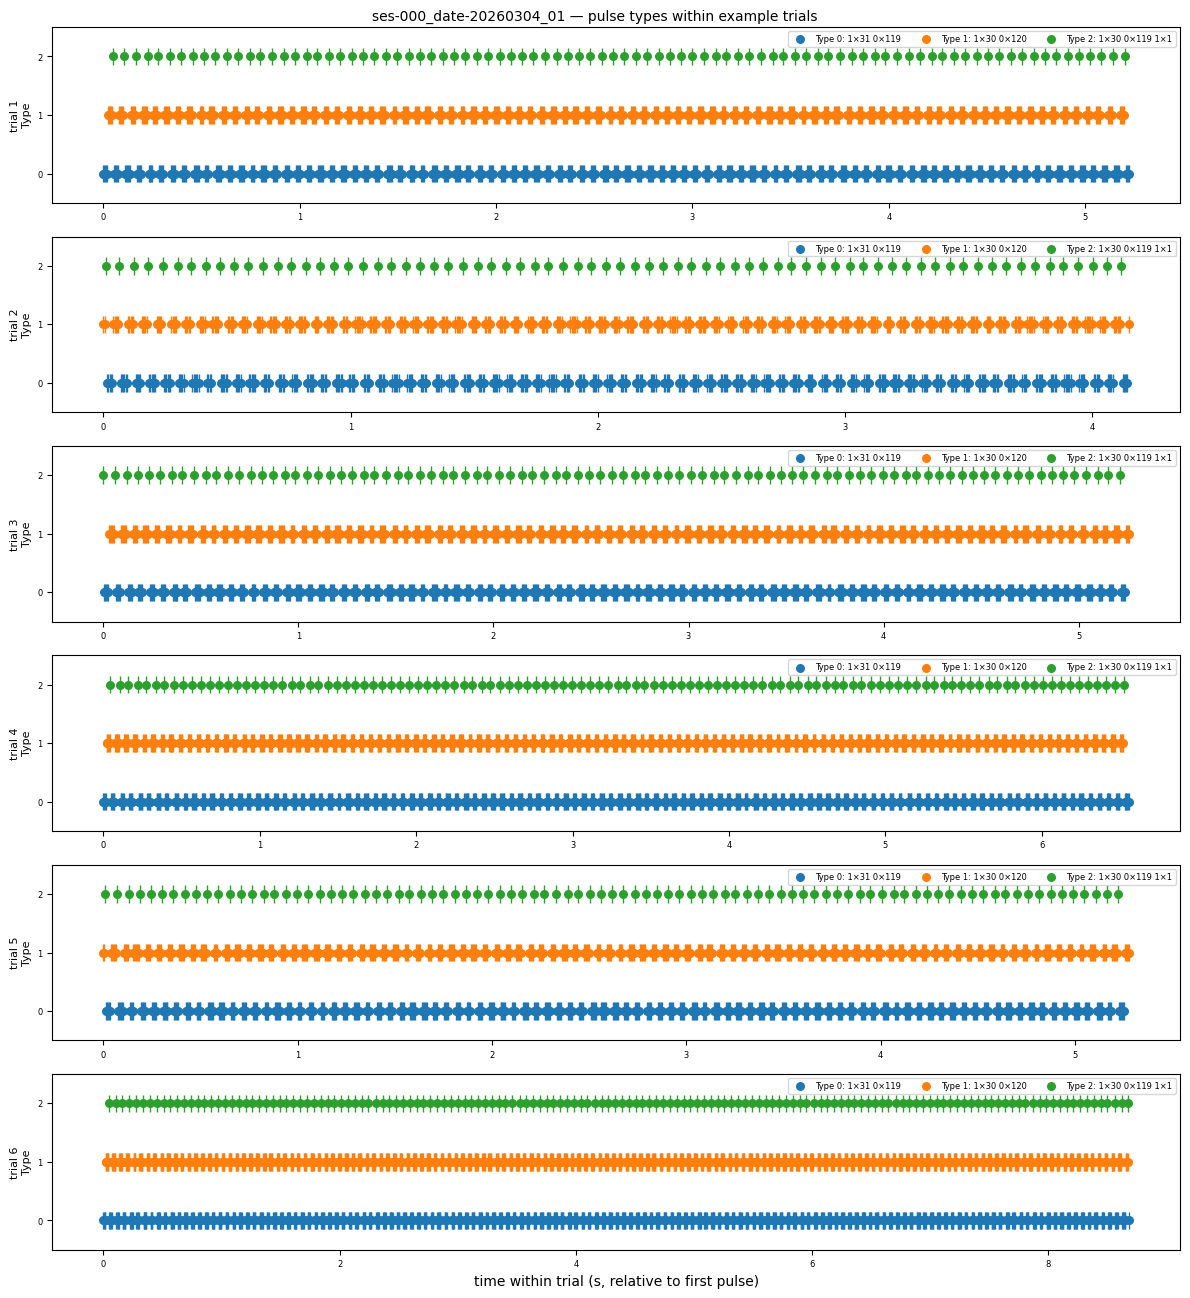

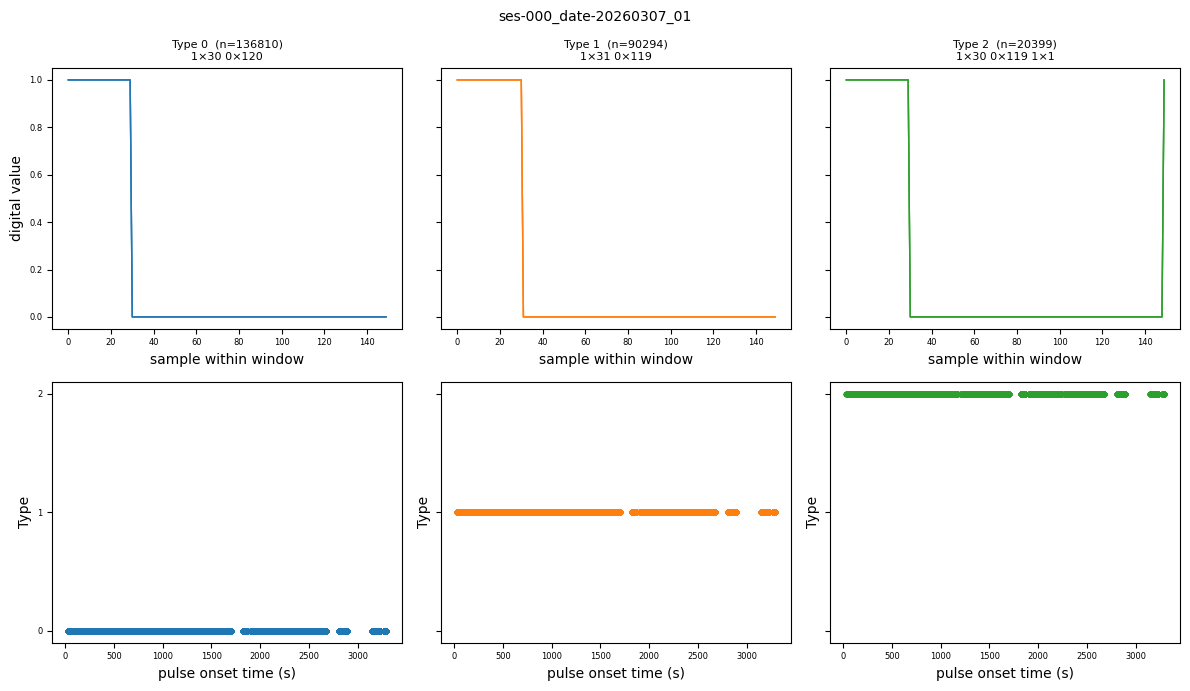

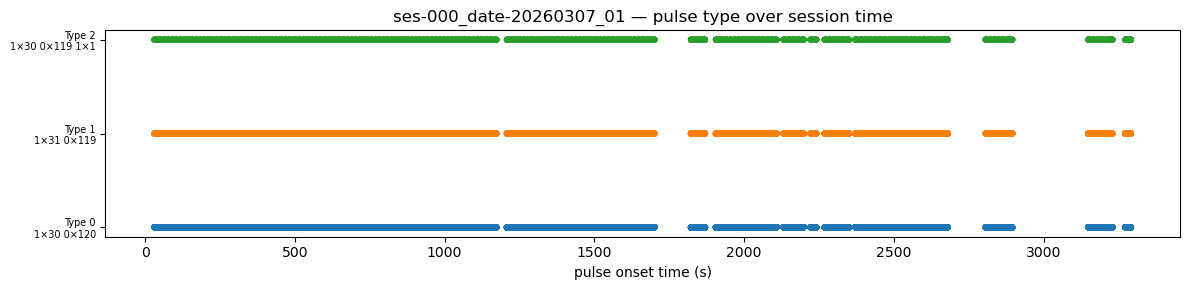

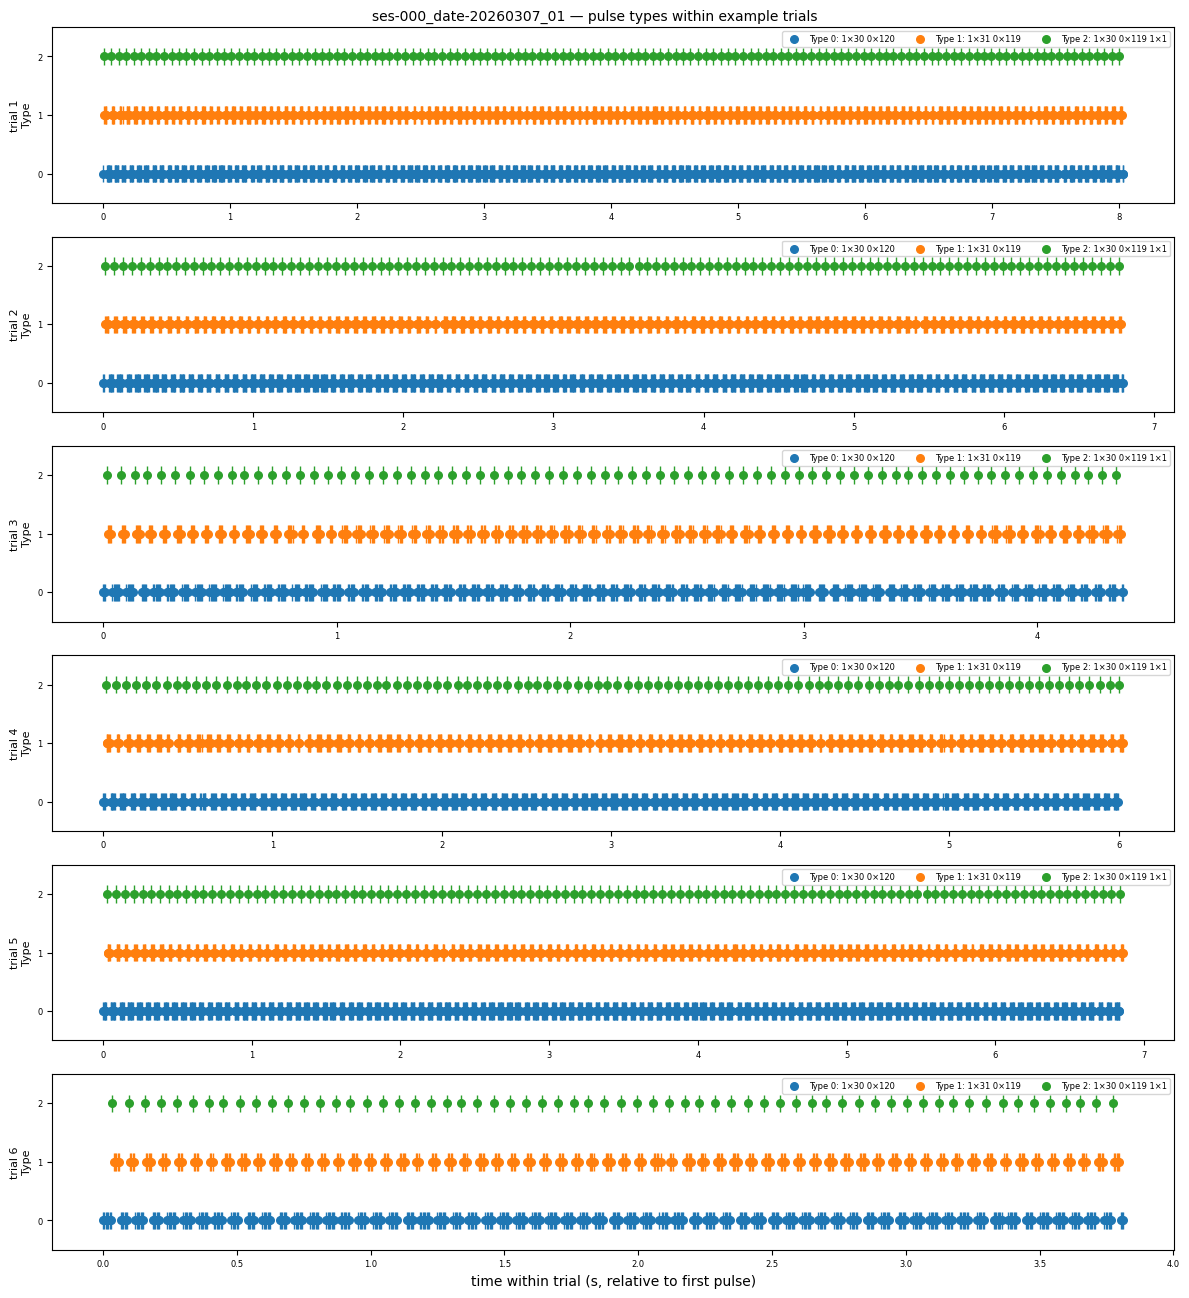

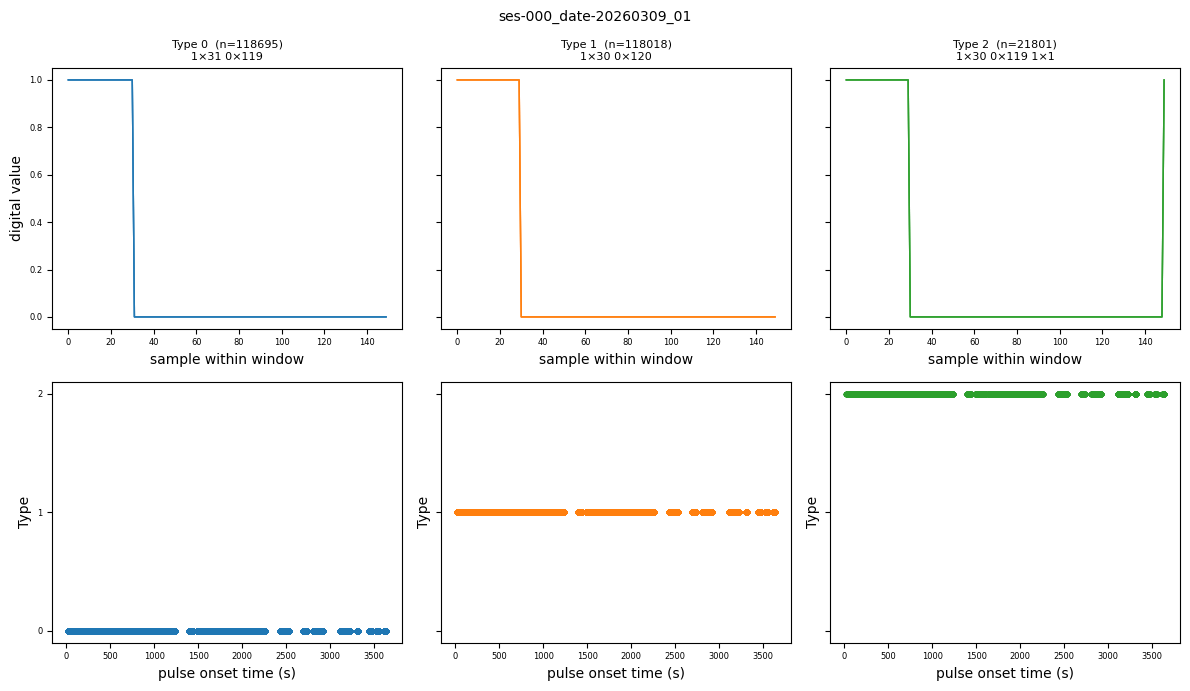

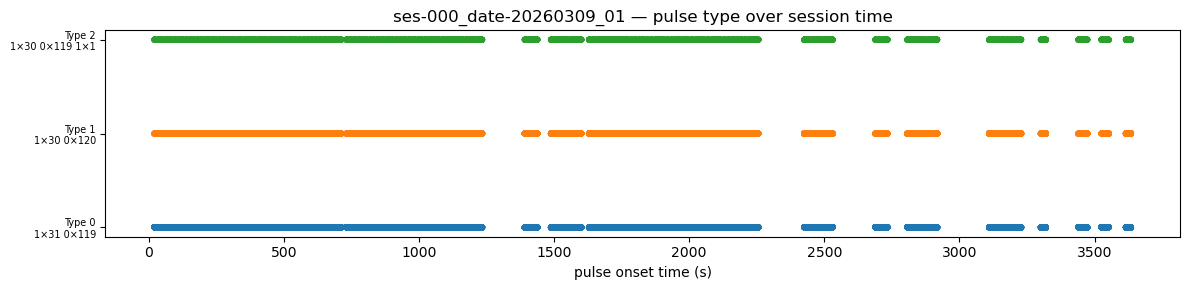

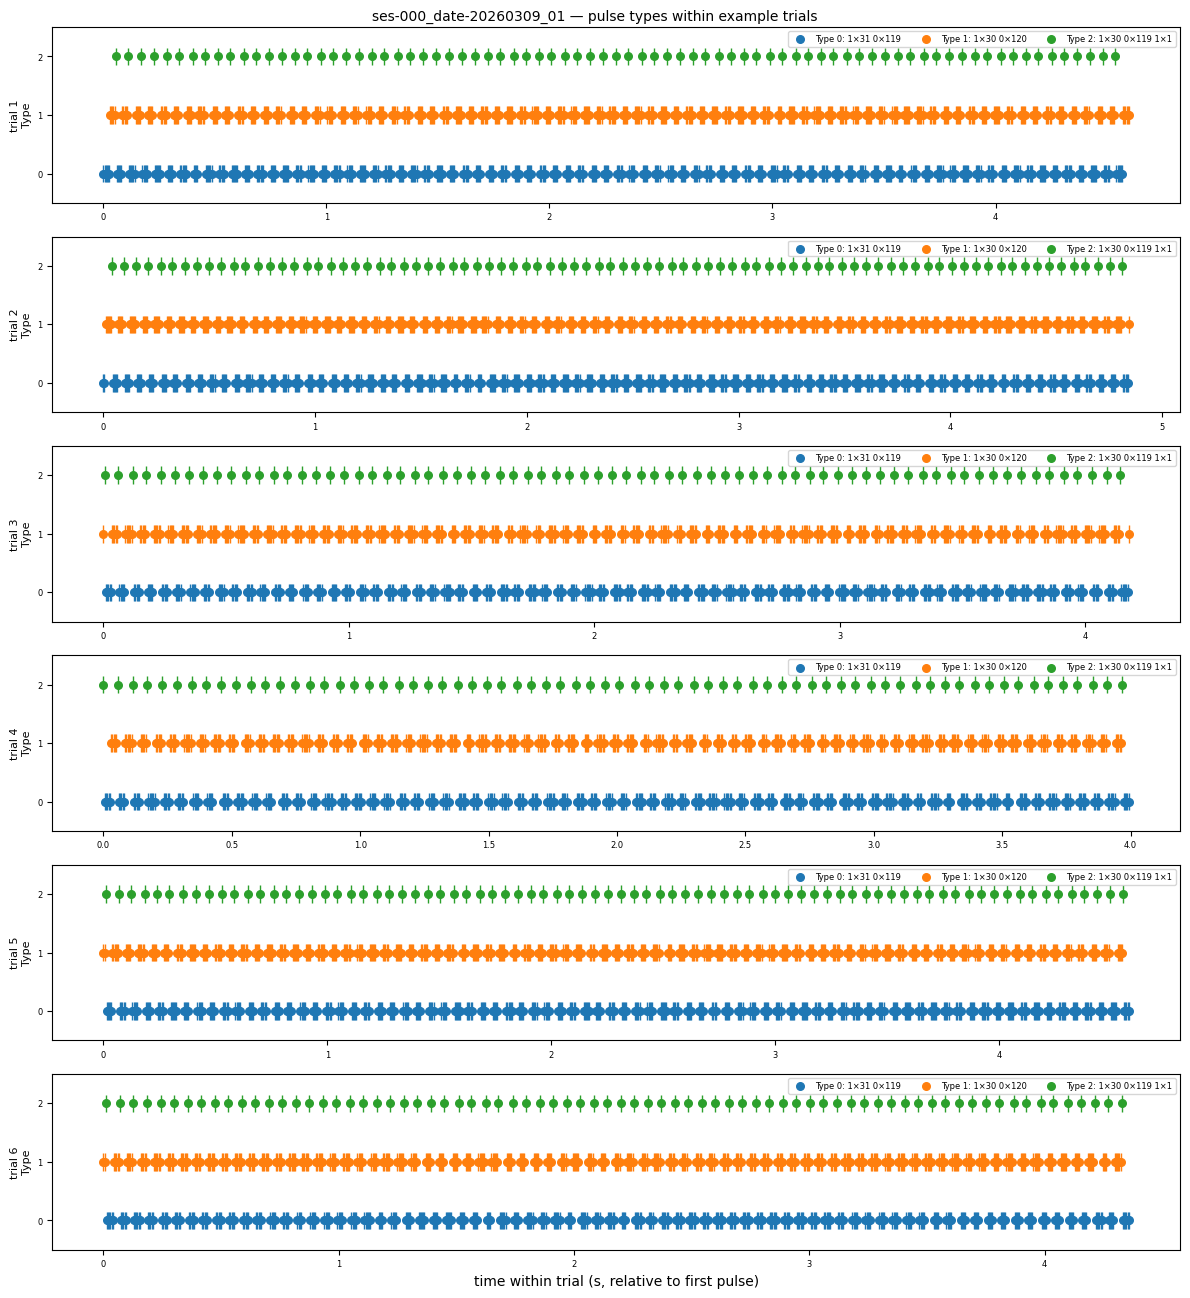

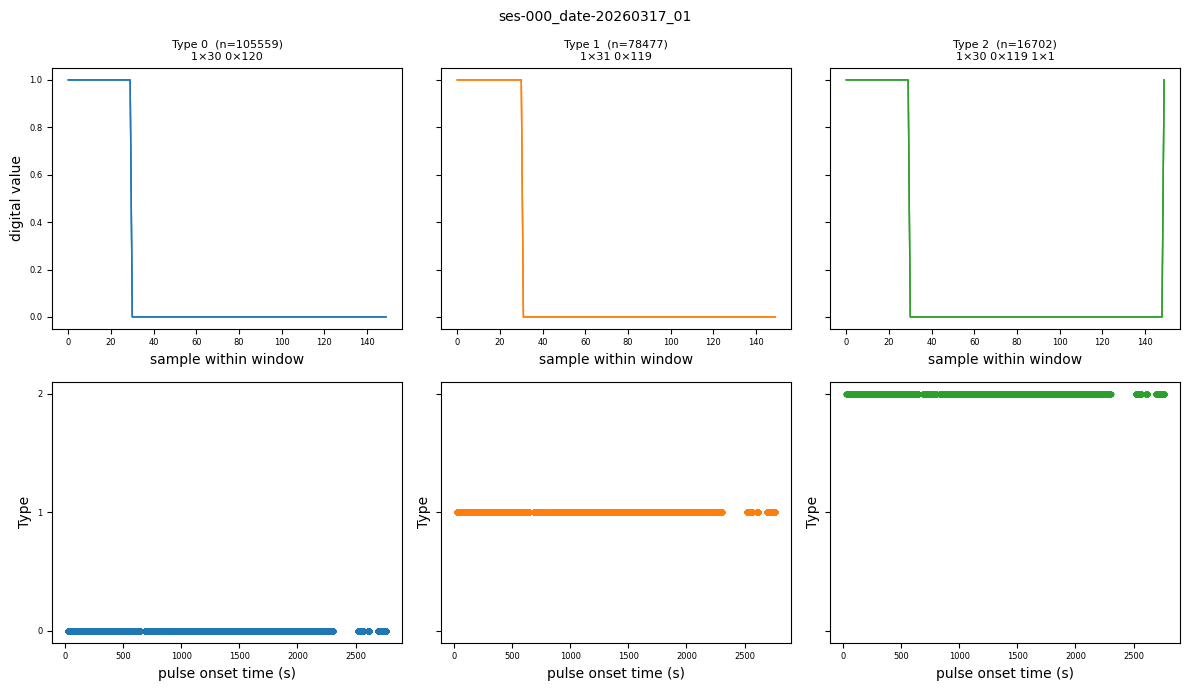

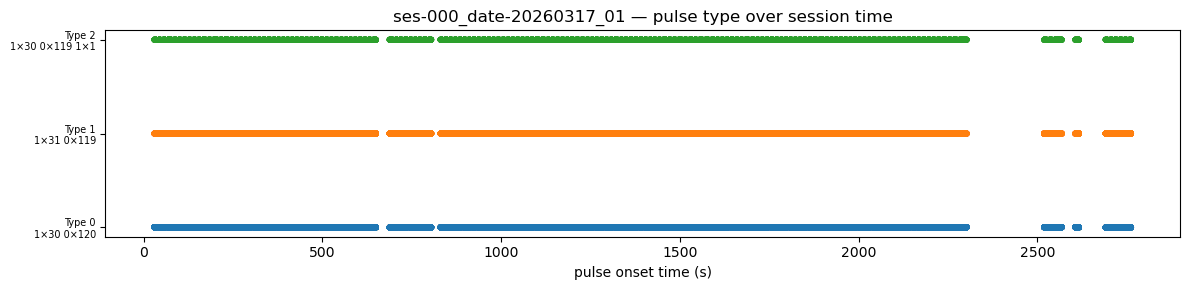

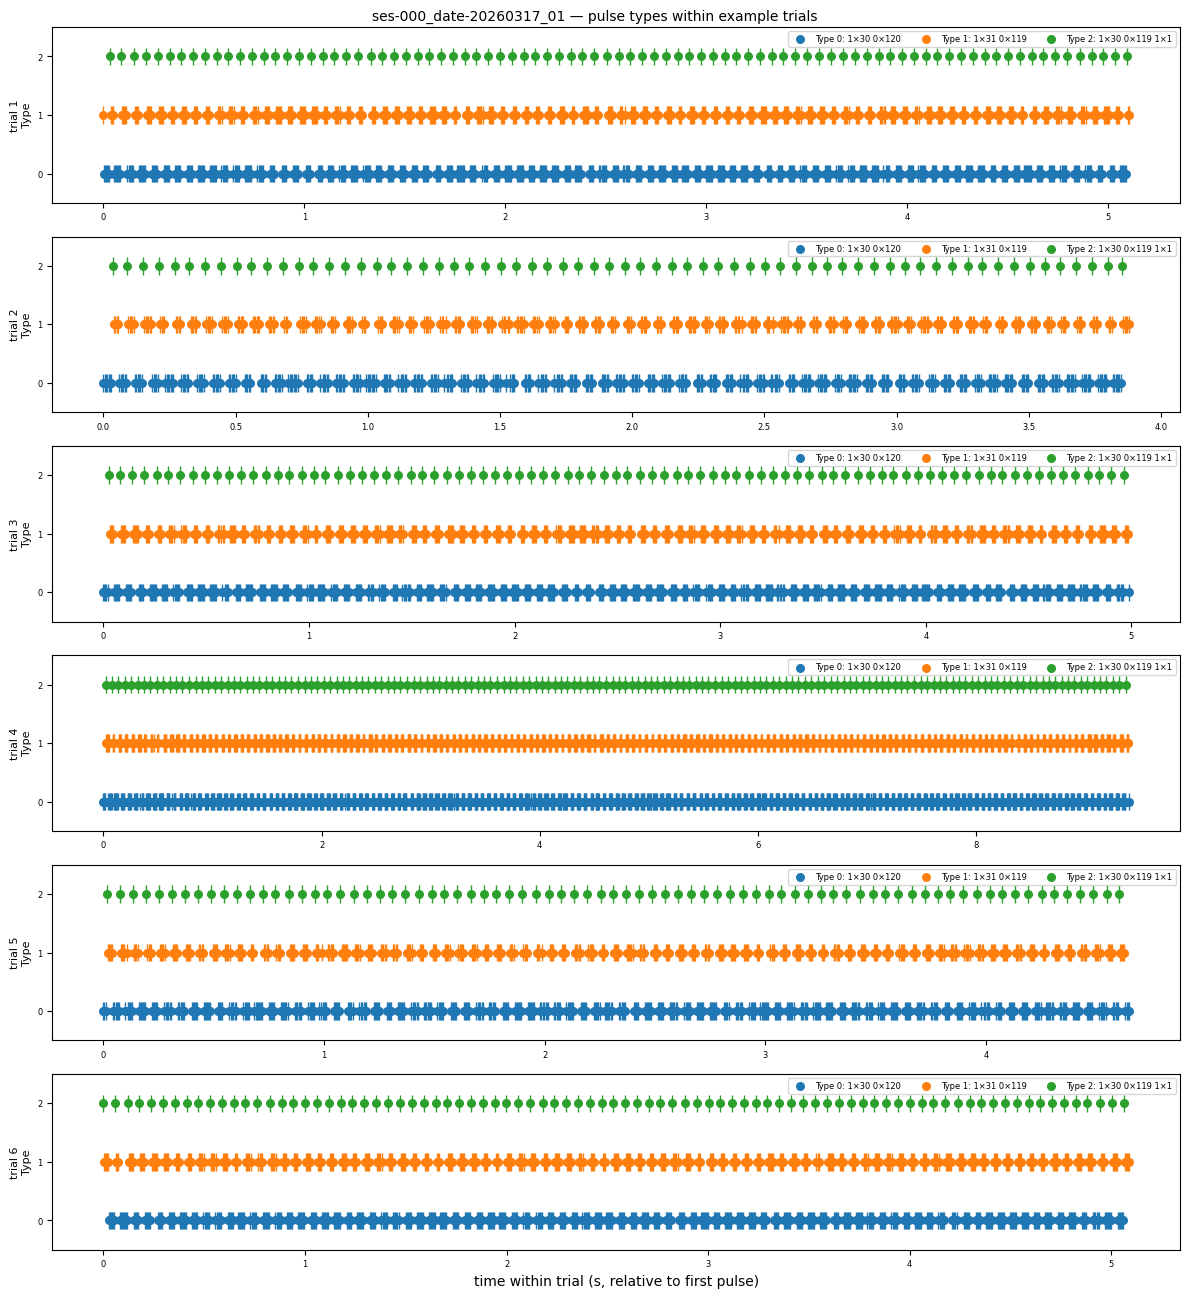

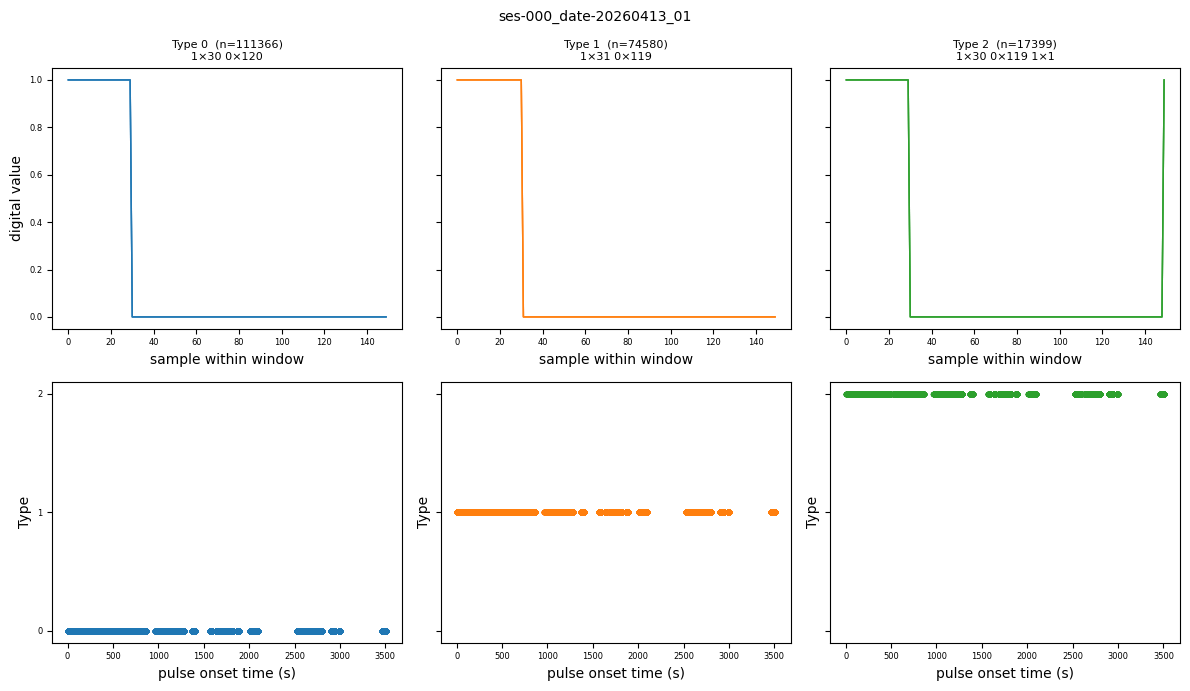

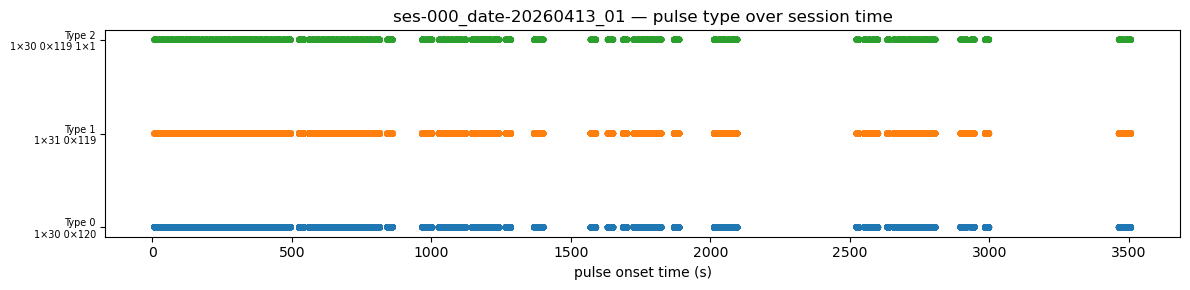

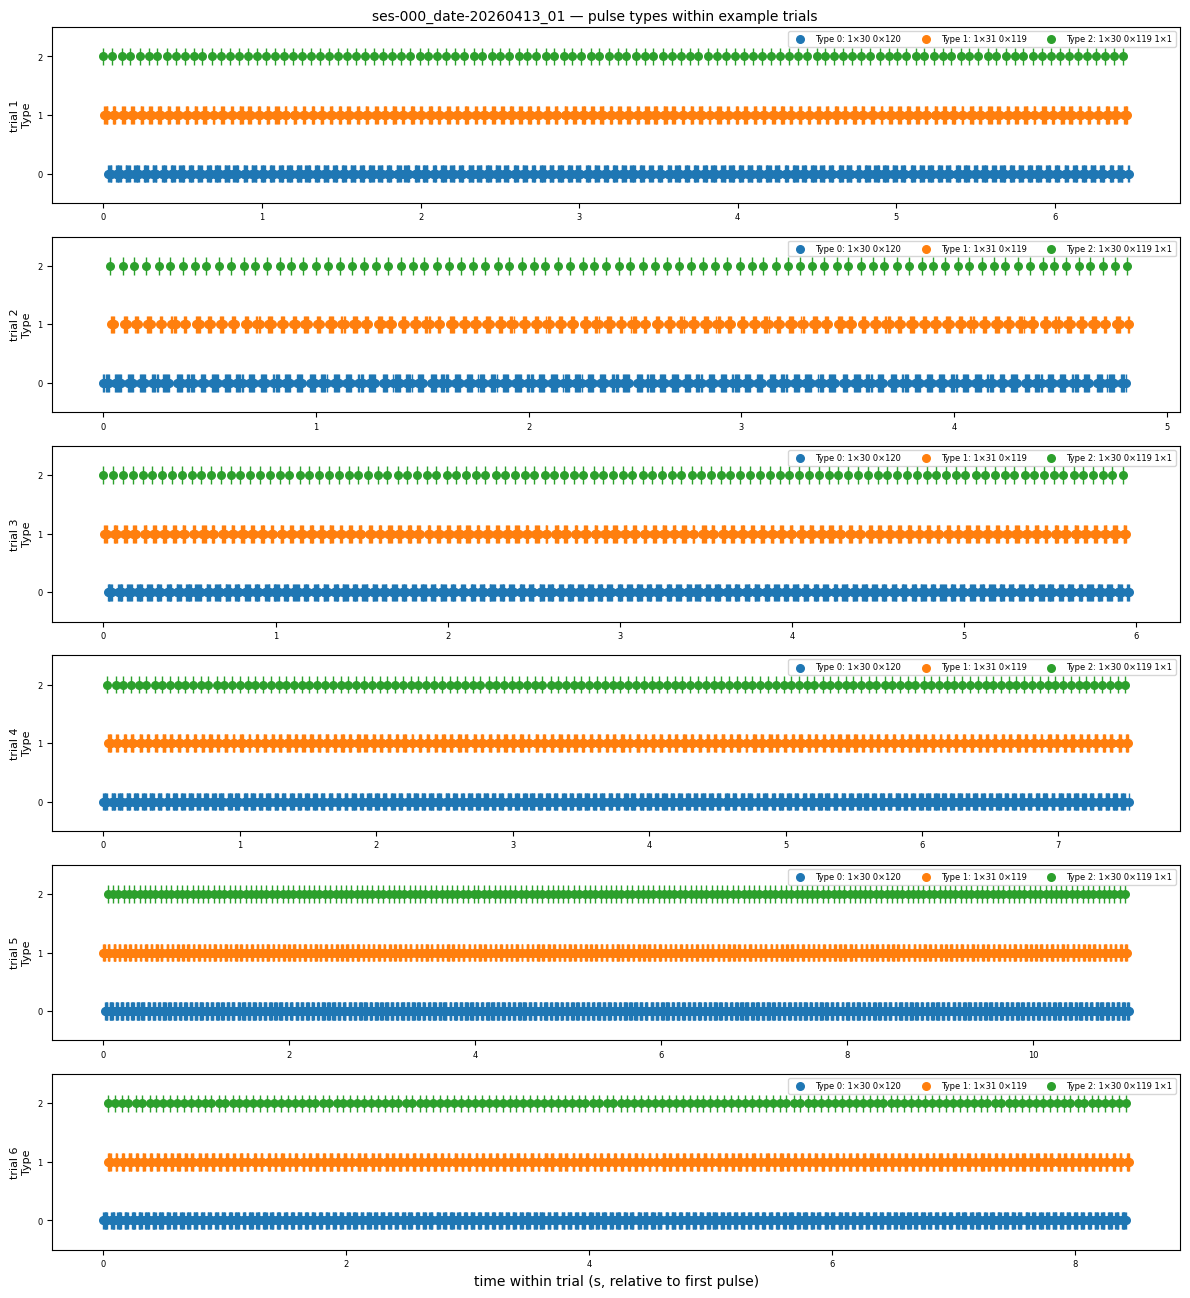

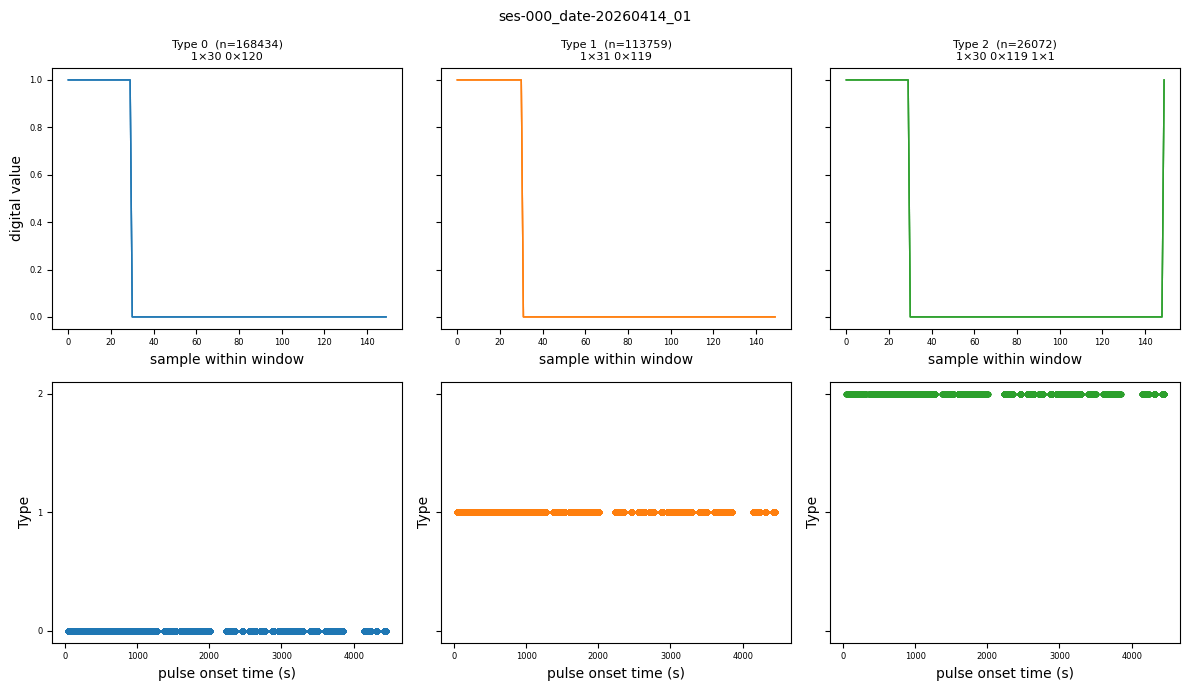

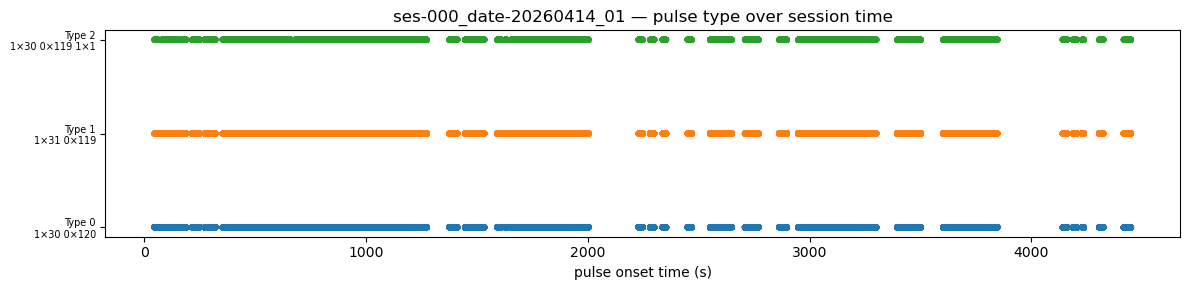

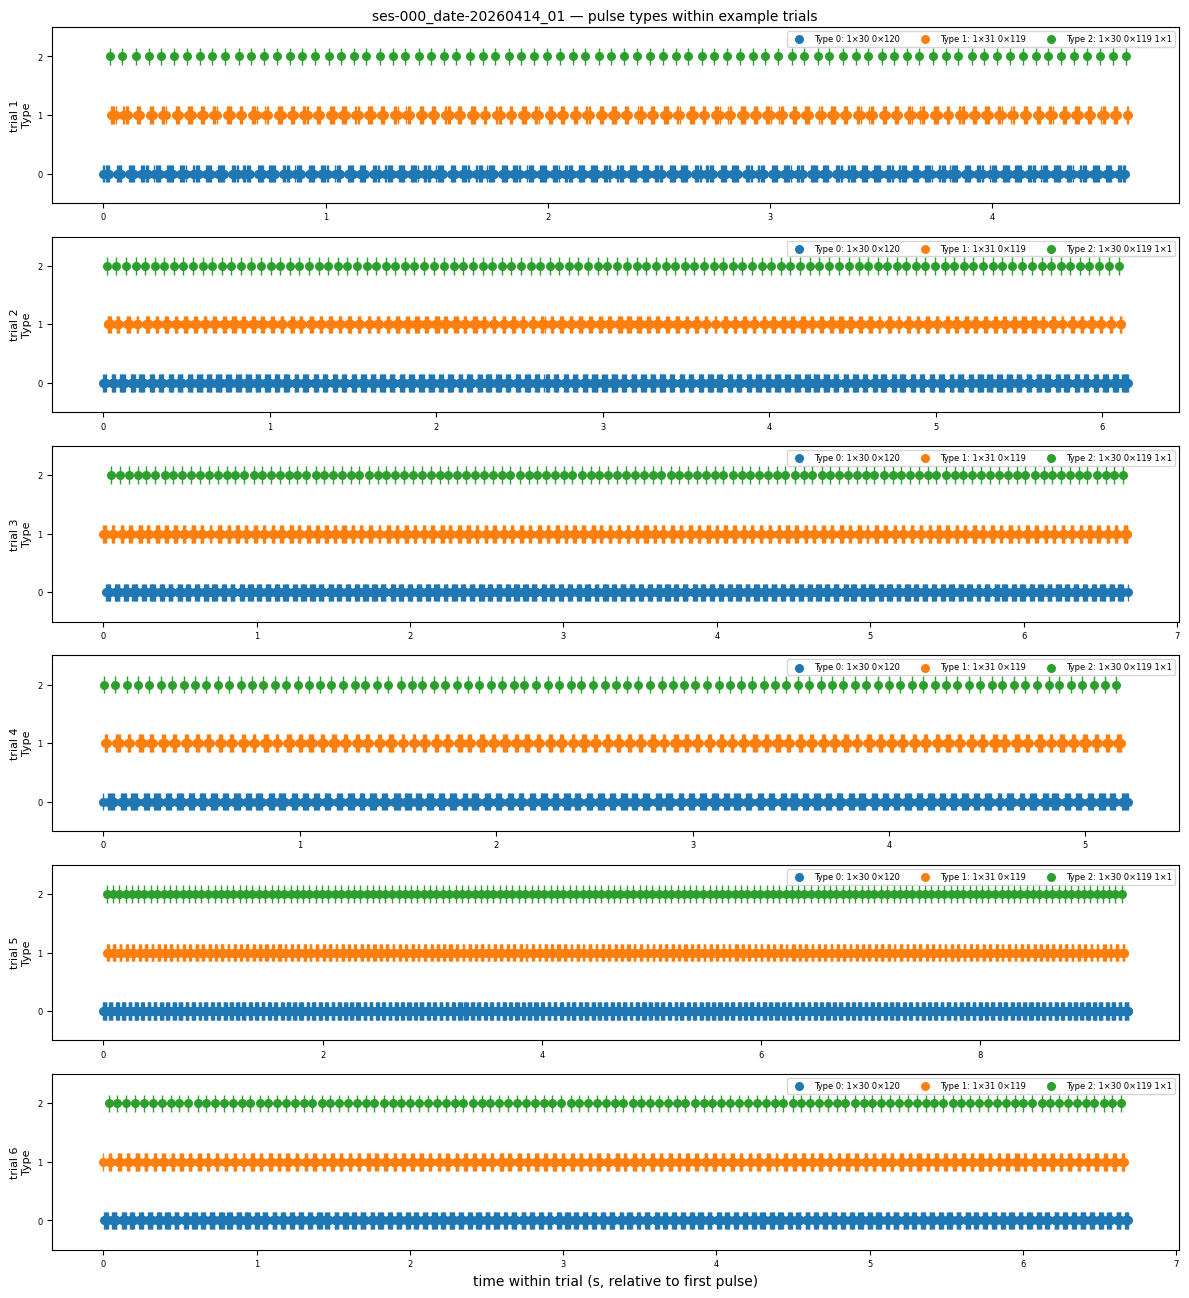

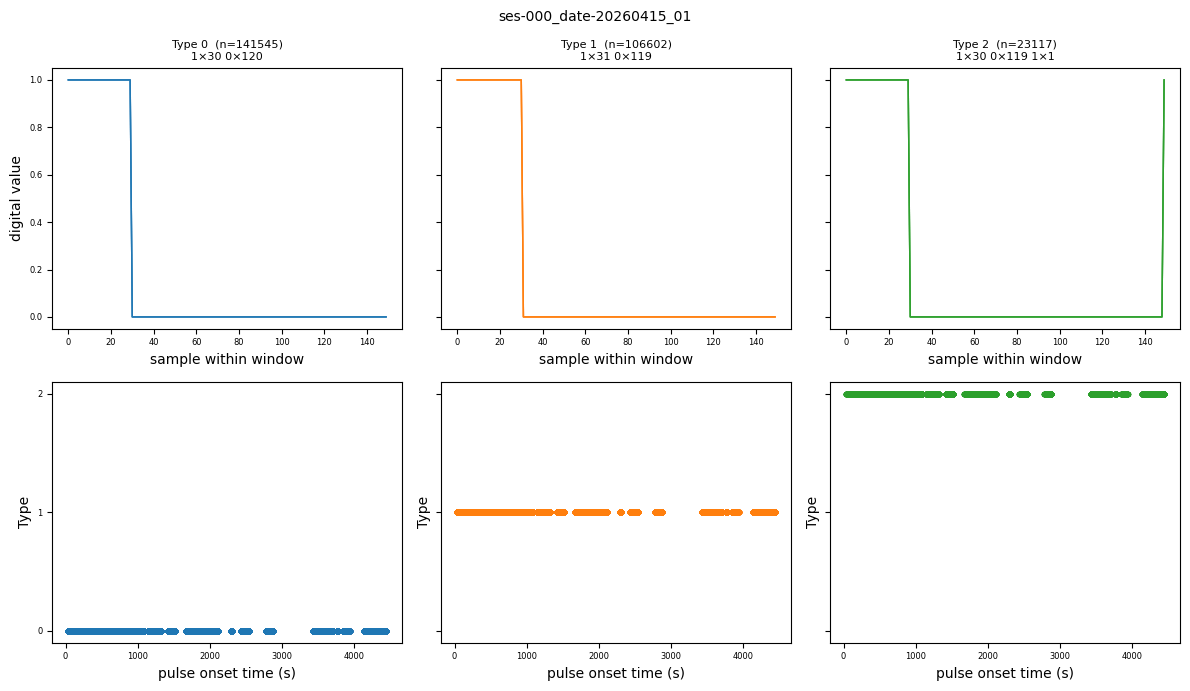

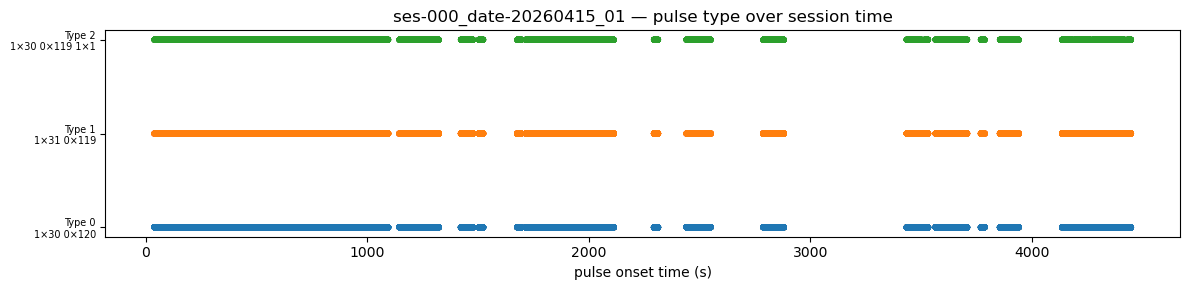

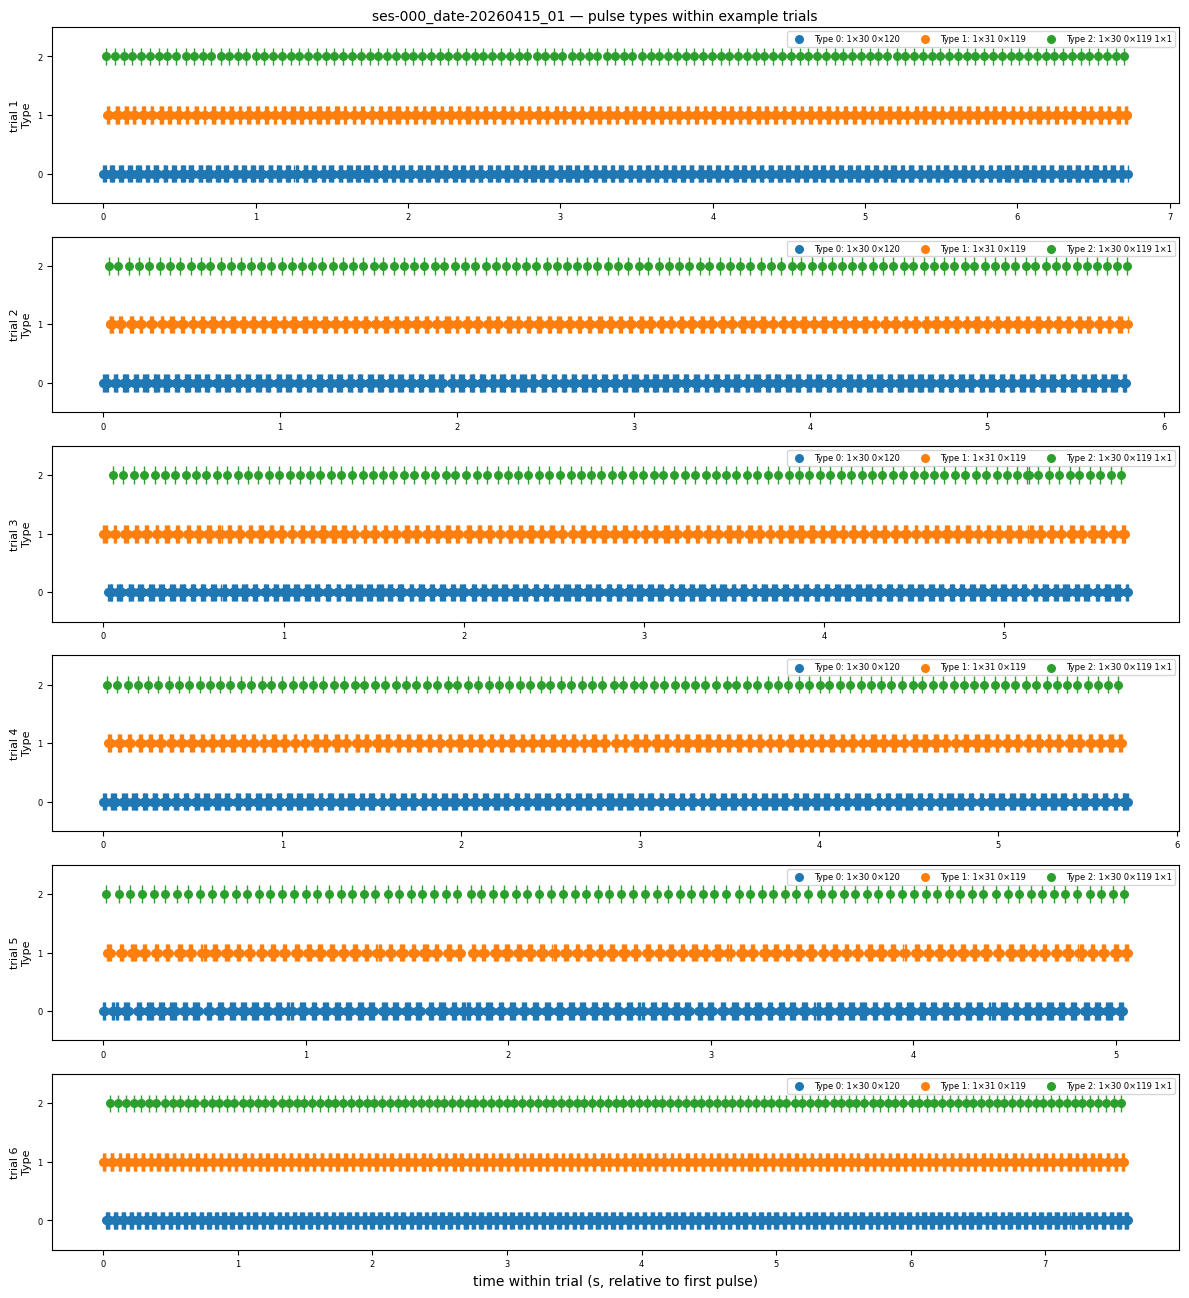

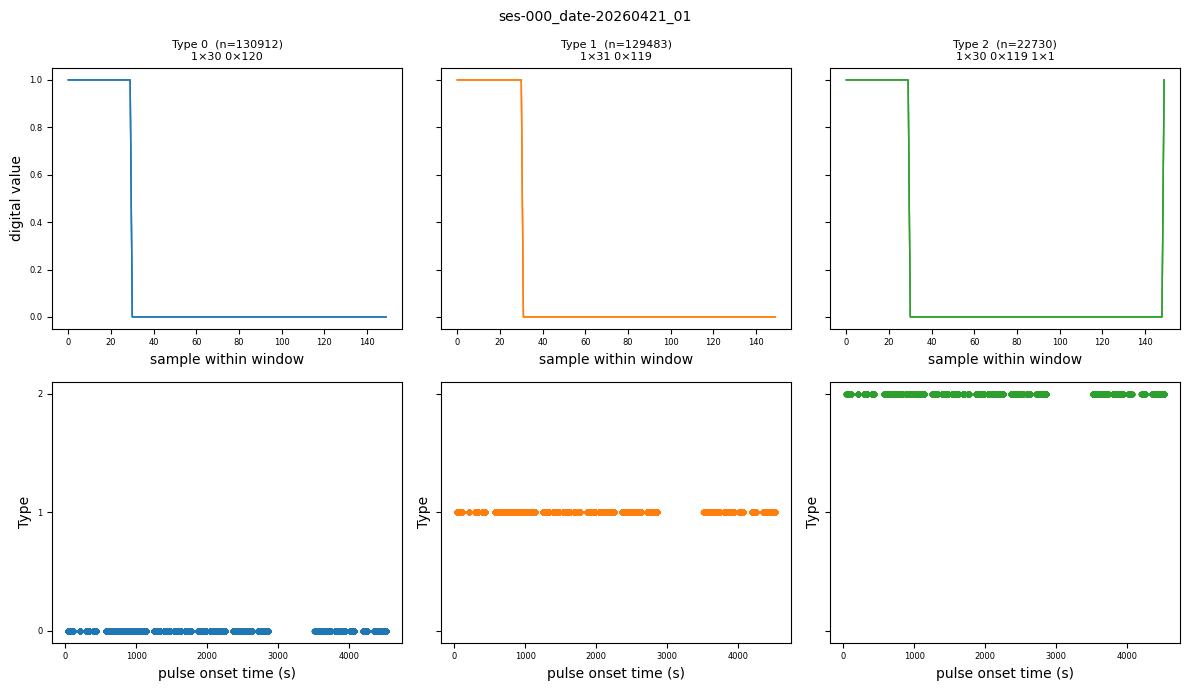

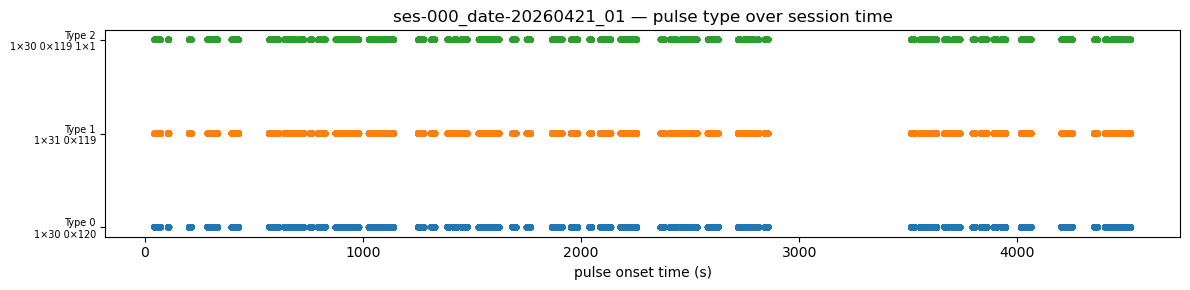

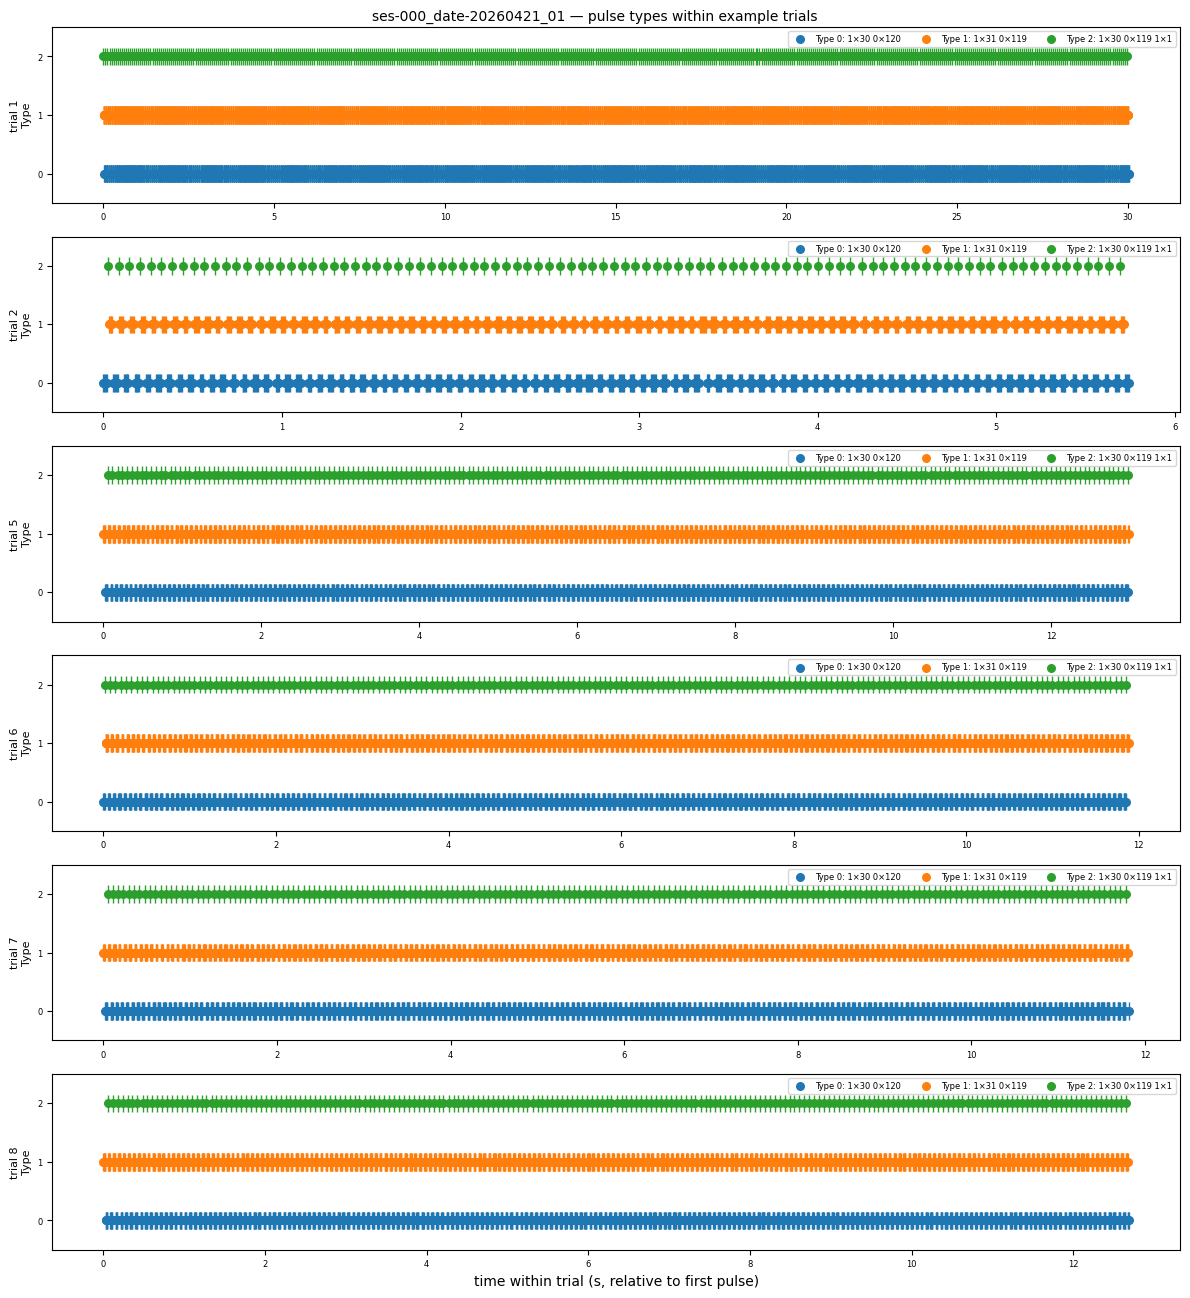

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ethograph as eto

from ethograph.io.ephys_loader import load_ephys

path_rhds = [
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-02_id-Poppy\ses-000_date-20260304_01\ephys\Poppy_260304_110818\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-02_id-Poppy\ses-000_date-20260307_01\ephys\Poppy_260307_113858\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-02_id-Poppy\ses-000_date-20260309_01\ephys\Poppy_260309_111034\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-02_id-Poppy\ses-000_date-20260317_01\ephys\Poppy_260317_192004\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-01_id-Ivy\ses-000_date-20260413_01\ephys\Ivy_260413_112833\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-01_id-Ivy\ses-000_date-20260414_01\ephys\Ivy_260414_125752\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-01_id-Ivy\ses-000_date-20260415_01\ephys\Ivy_260415_115410\info.rhd",
    r"C:\Users\Admin\Documents\Akseli\AI_data\rawdata\sub-01_id-Ivy\ses-000_date-20260421_01\ephys\Ivy_260421_182802\info.rhd",
]

path_labels = [
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-02_id-Poppy\ses-000_date-20260304_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-02_id-Poppy\ses-000_date-20260307_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-02_id-Poppy\ses-000_date-20260309_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-02_id-Poppy\ses-000_date-20260317_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-01_id-Ivy\ses-000_date-20260413_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-01_id-Ivy\ses-000_date-20260414_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-01_id-Ivy\ses-000_date-20260415_01\behav\Trial_data.nc",
    r"C:\Users\Admin\Documents\Akseli\AI_data\derivatives\sub-01_id-Ivy\ses-000_date-20260421_01\behav\Trial_data.nc",
]

window = 150
sr = 30_000
n_examples = 5
n_example_trials = 6
cmap = plt.cm.tab10


def run_lengths(signal):
    change_points = np.flatnonzero(np.diff(signal)) + 1
    bounds = np.concatenate(([0], change_points, [signal.size]))
    values = signal[bounds[:-1]]
    lengths = np.diff(bounds)
    return values, lengths


def pattern_label(signal):
    values, lengths = run_lengths(signal)
    return " ".join(f"{v}×{n}" for v, n in zip(values, lengths))


for label, rhd in zip(path_labels, path_rhds):
    loader = load_ephys(rhd, stream_id="4")
    dt = eto.open(label)

    signal = np.asarray(loader[:]).squeeze()

    pulse_lists = []
    trial_ids = []
    for trial in dt.trials:
        onsets = dt.trial(trial).pulse_onsets.values
        pulse_lists.append(onsets)
        trial_ids.append(np.full(len(onsets), trial))
    pulses = np.concatenate(pulse_lists).astype(np.intp)
    pulse_trial = np.concatenate(trial_ids)

    offsets = np.arange(window)
    windows = signal[pulses[:, None] + offsets]

    flat = np.ascontiguousarray(windows).reshape(windows.shape[0], -1)
    patterns, inverse, counts = np.unique(
        flat, axis=0, return_inverse=True, return_counts=True
    )

    order = np.argsort(counts)[::-1]
    rank_of_cluster = np.empty(order.size, dtype=int)
    rank_of_cluster[order] = np.arange(order.size)
    pulse_rank = rank_of_cluster[inverse]

    labels = {
        rank: pattern_label(patterns[cluster].astype(int))
        for rank, cluster in enumerate(order)
    }

    pulse_time_s = pulses / sr
    session_name = label.split("\\")[-3]
    n_clusters = order.size

    fig, axes = plt.subplots(
        2, n_clusters, figsize=(4 * n_clusters, 7),
        sharex="row", sharey="row",
    )
    axes = np.atleast_2d(axes)

    for rank, cluster in enumerate(order):
        member_idx = np.flatnonzero(pulse_rank == rank)
        sample = member_idx[
            np.linspace(
                0, member_idx.size - 1, min(n_examples, member_idx.size)
            ).astype(int)
        ]

        ax = axes[0, rank]
        for idx in sample:
            ax.plot(
                np.asarray(windows[idx]).squeeze().astype(int),
                alpha=0.6, lw=1, color=cmap(rank % 10),
            )
        ax.set_title(
            f"Type {rank}  (n={counts[cluster]})\n{labels[rank]}",
            fontsize=8,
        )
        ax.set_xlabel("sample within window")
        ax.tick_params(labelsize=6)

        ax2 = axes[1, rank]
        ax2.scatter(
            pulse_time_s[member_idx],
            np.full(member_idx.size, rank),
            s=8, alpha=0.5, color=cmap(rank % 10),
        )
        ax2.set_yticks(range(n_clusters))
        ax2.set_xlabel("pulse onset time (s)")
        ax2.set_ylabel("Type")
        ax2.tick_params(labelsize=6)

    axes[0, 0].set_ylabel("digital value")
    fig.suptitle(session_name, fontsize=10)
    fig.tight_layout()
    plt.show()

    fig2, ax = plt.subplots(figsize=(12, 3))
    ax.scatter(
        pulse_time_s, pulse_rank,
        c=cmap(pulse_rank % 10), s=10,
    )
    ax.set_yticks(range(n_clusters))
    ax.set_yticklabels(
        [f"Type {r}\n{labels[r]}" for r in range(n_clusters)], fontsize=7
    )
    ax.set_xlabel("pulse onset time (s)")
    ax.set_title(f"{session_name} — pulse type over session time")
    fig2.tight_layout()
    plt.show()

    trials_with_pulses = [t for t in dt.trials if np.any(pulse_trial == t)]
    example_trials = trials_with_pulses[:n_example_trials]
    n = len(example_trials)

    fig3, axes3 = plt.subplots(
        n, 1, figsize=(12, 2.2 * n), squeeze=False,
    )

    for ax, trial in zip(axes3[:, 0], example_trials):
        mask = pulse_trial == trial
        t_pulses = pulses[mask]
        t_ranks = pulse_rank[mask]
        rel_s = (t_pulses - t_pulses.min()) / sr

        for rank in np.unique(t_ranks):
            sel = t_ranks == rank
            ax.scatter(
                rel_s[sel], t_ranks[sel],
                c=[cmap(rank % 10)], s=30,
                label=f"Type {rank}: {labels[rank]}",
            )
            ax.vlines(
                rel_s[sel], rank - 0.15, rank + 0.15,
                colors=[cmap(rank % 10)], lw=1,
            )

        ax.set_yticks(range(n_clusters))
        ax.set_ylim(-0.5, n_clusters - 0.5)
        ax.set_ylabel(f"trial {trial}\nType", fontsize=8)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6, loc="upper right", ncol=n_clusters)

    axes3[-1, 0].set_xlabel(
        "time within trial (s, relative to first pulse)"
    )
    fig3.suptitle(
        f"{session_name} — pulse types within example trials", fontsize=10
    )
    fig3.tight_layout()
    plt.show()

    dt.close()

In [30]:
representatives

{np.int64(0): np.int64(1), np.int64(2): np.int64(0), np.int64(1): np.int64(7)}

In [32]:
import numpy as np
import pandas as pd

flat = np.ascontiguousarray(windows).reshape(windows.shape[0], -1)
patterns, inverse, counts = np.unique(
    flat, axis=0, return_inverse=True, return_counts=True
)

order = np.argsort(counts)[::-1]

df = pd.DataFrame(
    patterns[order],
    columns=[f"s{i}" for i in range(patterns.shape[1])],
)
df.insert(0, "count", counts[order])
df.index.name = "pattern"
df

,count,s0,s1,s2,s3,s4,s5,s6,s7,s8,...,s140,s141,s142,s143,s144,s145,s146,s147,s148,s149
pattern,,,,,,,,,,,,,,,,,,,,,
0,5723,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4296,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,930,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


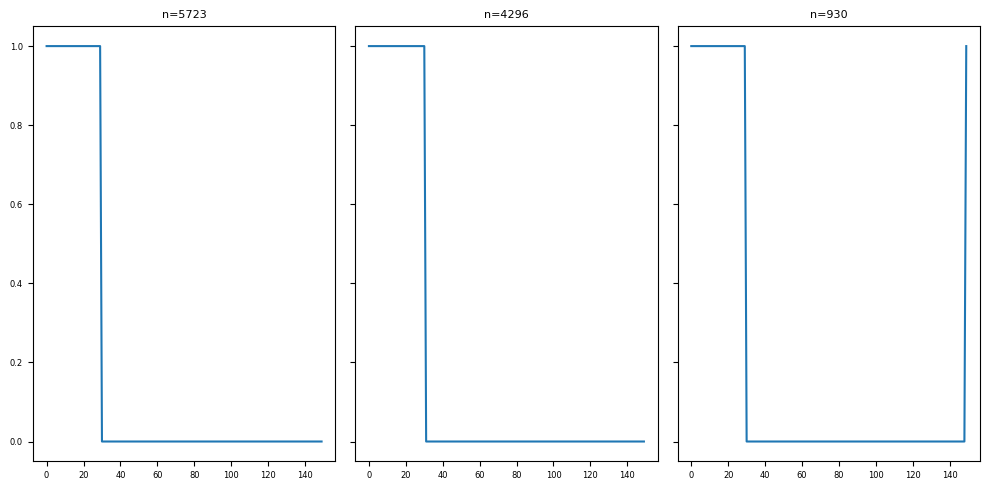

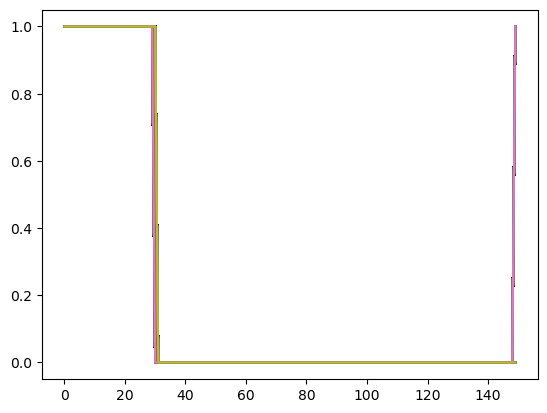

In [15]:
windows.shape

(10949, 150, 1)

In [8]:
dt.trial(1).pulse_onsets.values

array([ 906117,  906267,  906417, ..., 1058881, 1059030, 1059180],
      dtype=int32)

In [7]:
dt.trial(10).pulse_onsets.values

array([4598223, 4598373, 4598523, 4598673, 4598823, 4598973, 4599122,
       4599272, 4599422, 4599572, 4599722, 4599872, 4600022, 4600172,
       4600322, 4600472, 4600622, 4600772, 4600921, 4601071, 4601221,
       4601371, 4601521, 4601671, 4601821, 4601971, 4602121, 4602271,
       4602421, 4602571, 4602720, 4602870, 4603020, 4603170, 4603320,
       4603470, 4603620, 4603770, 4603920, 4604070, 4604220, 4604370,
       4604519, 4604669, 4604819, 4604969, 4605119, 4605269, 4605419,
       4605569, 4605719, 4605869, 4606019, 4606168, 4606318, 4606468,
       4606618, 4606768, 4606918, 4607068, 4607218, 4607368, 4607518,
       4607668, 4607818, 4607967, 4608117, 4608267, 4608417, 4608567,
       4608717, 4608867, 4609017, 4609167, 4609317, 4609467, 4609617,
       4609766, 4609916, 4610066, 4610216, 4610366, 4610516, 4610666,
       4610816, 4610966, 4611116, 4611266, 4611416, 4611565, 4611715,
       4611865, 4612015, 4612165, 4612315, 4612465, 4612615, 4612765,
       4612915, 4613

In [6]:
import ethograph as eto

dt = eto.open(path_labels[0])
dt

<xarray.DataTree>
Group: /
│   Attributes:
│       session:  2026-03-04_01
├── Group: /1
│       Dimensions:                     (time: 1046, space: 3, keypoints: 3,
│                                        individuals: 1, s3d_dims: 20, RGB: 3, events: 4)
│       Coordinates:
│         * time                        (time) float64 8kB 0.0 0.005 0.01 ... 5.22 5.225
│         * space                       (space) <U1 12B 'x' 'y' 'z'
│         * keypoints                   (keypoints) <U8 96B 'beakTip' ... 'pellet'
│         * individuals                 (individuals) <U5 20B 'Poppy'
│       Dimensions without coordinates: s3d_dims, RGB, events
│       Data variables: (12/27)
│           position                    (time, space, keypoints, individuals) float64 75kB ...
│           confidence                  (time, keypoints, individuals) float32 13kB ...
│           velocity                    (time, space, keypoints, individuals) float64 75kB ...
│           speed                       (time, keypoints, individuals) float64 25kB ...
│           acceleration                (time, space, keypoints, individuals) float64 75kB ...
│           pellet_beakTip_dist         (time) float64 8kB ...
│           ...                          ...
│           angle_rgb                   (keypoints, individuals, time, RGB) float64 75kB ...
│           boundary_events             (events) float64 32B ...
│           pulse_onsets                (time) int32 4kB ...
│           aux_acceleration            (time, space) float64 25kB ...
│           aux_velocity                (time, space) float64 25kB ...
│           aux_speed                   (time) float64 8kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:        seconds
│           source_file:      D:/Akseli/AI_data/rawdata/sub-02_id-Poppy/ses-000_date-...
│           trial:            1
│           session:          2026-03-04_01
│           bird:             Poppy
│           poscat:           3
│           num_pellets:      1
├── Group: /2
│       Dimensions:                     (time: 831, space: 3, keypoints: 3,
│                                        individuals: 1, s3d_dims: 20, RGB: 3, events: 4)
│       Coordinates:
│         * time                        (time) float64 7kB 0.0 0.005 0.01 ... 4.145 4.15
│         * space                       (space) <U1 12B 'x' 'y' 'z'
│         * keypoints                   (keypoints) <U8 96B 'beakTip' ... 'pellet'
│         * individuals                 (individuals) <U5 20B 'Poppy'
│       Dimensions without coordinates: s3d_dims, RGB, events
│       Data variables: (12/27)
│           position                    (time, space, keypoints, individuals) float64 60kB ...
│           confidence                  (time, keypoints, individuals) float32 10kB ...
│           velocity                    (time, space, keypoints, individuals) float64 60kB ...
│           speed                       (time, keypoints, individuals) float64 20kB ...
│           acceleration                (time, space, keypoints, individuals) float64 60kB ...
│           pellet_beakTip_dist         (time) float64 7kB ...
│           ...                          ...
│           angle_rgb                   (keypoints, individuals, time, RGB) float64 60kB ...
│           boundary_events             (events) float64 32B ...
│           pulse_onsets                (time) int32 3kB ...
│           aux_acceleration            (time, space) float64 20kB ...
│           aux_velocity                (time, space) float64 20kB ...
│           aux_speed                   (time) float64 7kB ...
│       Attributes:
│           source_software:  DeepLabCut
│           ds_type:          poses
│           fps:              200.0
│           time_unit:        seconds
│           source_file:      D:/Akseli/AI_data/rawdata/sub-02_id-Poppy/ses-000_date-...
│           trial:            2


np.int32(1779038)

### Realization

Although, stream_id = "1" (accelerometer) is sampled at 7500Hz, we still have to set `sr=30_000`, since sample to time mapping is specified via the general sr of the recording system.

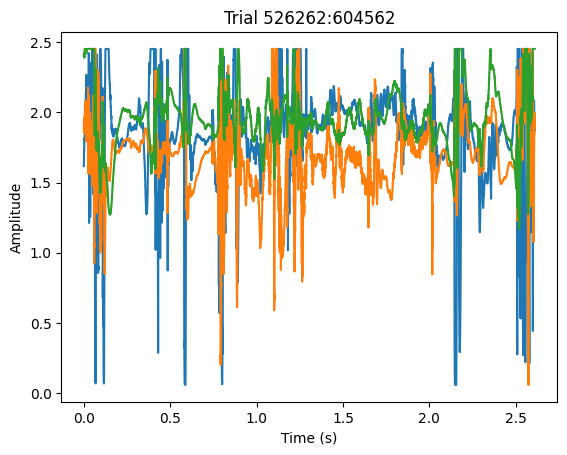

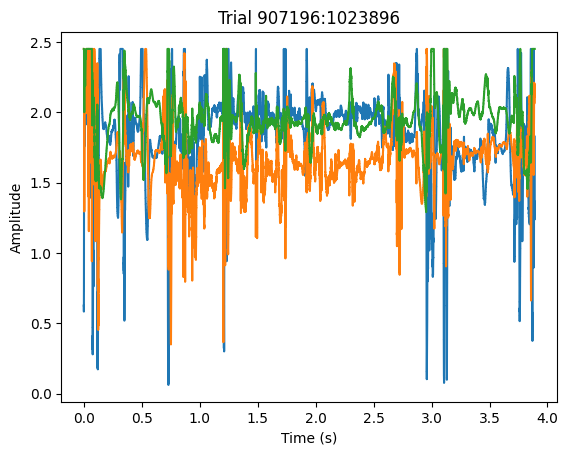

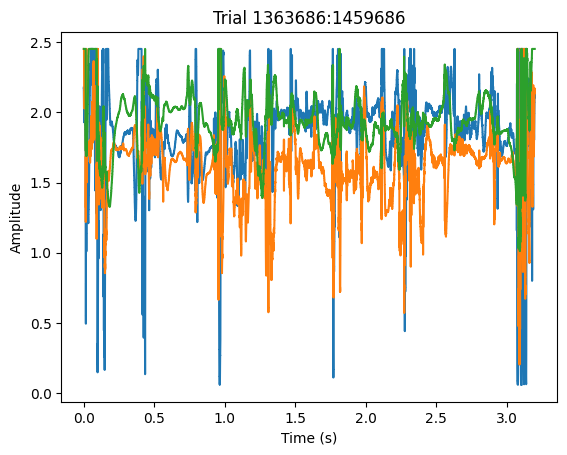

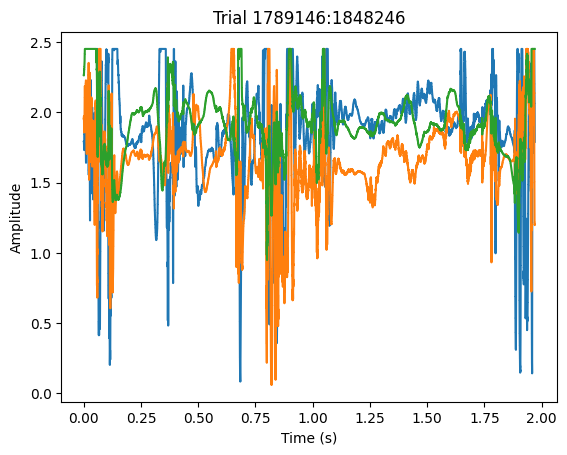

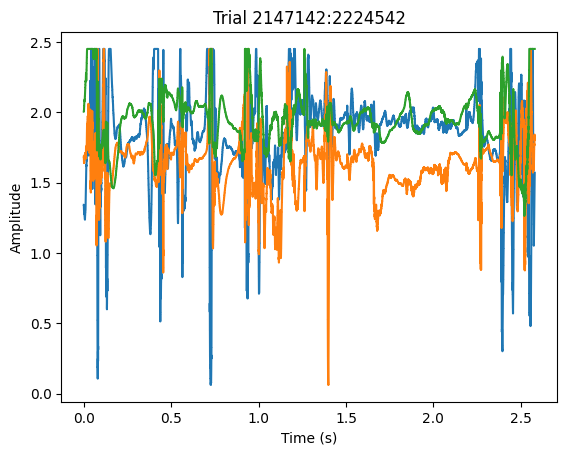

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ethograph.io.ephys_loader import load_ephys

path_labels = r"C:\Users\aksel\Desktop\POPPY_LABEL\ses-000_date-20260308_01\behav\Trial_data_labels.tsv"
path_rhd = r"C:\Users\aksel\Desktop\POPPY_LABEL\raw\ephys\Poppy_260308_115737\info.rhd"
sr = 30_000 # Sampling rate in Hz

df = pd.read_csv(path_labels, sep="\t")
start_idx = (df[df.labels == 1].drop_duplicates("trial", keep="first")["onset_global"] * sr).astype(int)
end_idx = (df[df.labels == 10].drop_duplicates("trial", keep="first")["offset_global"] * sr).astype(int)

loader = load_ephys(path_rhd, stream_id="1")

for s, e in zip(start_idx[:5], end_idx[:5]):  
    trace = loader[s:e]
    t = np.arange(len(trace)) / sr
    plt.plot(t, trace)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Trial {s}:{e}")
    plt.show()